## Load Data

In [32]:
# imports
import pandas as pd

In [ ]:
#Force pandas to display unlimited columns
pd.set_option('display.max_columns', None)

# Define the CSV file path
csv_file_path = r'stack-overflow-developer-survey-2025\survey_results_public.csv'

# Load the CSV into a DataFrame
try:
    df = pd.read_csv(csv_file_path)
    print("CSV loaded successfully.")
    
    # Display the info of the DataFrame
    print("\nDataFrame Info:")
    df.info()
    
    # Display the shape of the DataFrame
    print("-------------------------\n\nDataFrame Shape:")
    print(df.shape)
    
    # Display the head of the DataFrame
    print("-------------------------\n\nDataFrame Head:")
    print(df.head())
    
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please ensure it is correctly mounted and the path is correct.")
except Exception as e:
    print(f"An error occurred: {e}")

C:\Users\ingex\AppData\Local\Temp\ipykernel_19676\2178050755.py:9: DtypeWarning: Columns (18,19,29,30,31,32,33,34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_file_path)


CSV loaded successfully.

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53921 entries, 0 to 53920
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(34), object(138)
memory usage: 70.8+ MB
-------------------------

DataFrame Shape:
(53921, 172)
-------------------------

DataFrame Head:
  ResponseId                      MainBranch              Age  \
0          1  I am a developer by profession  25-34 years old   
1          2  I am a developer by profession  25-34 years old   
2          3  I am a developer by profession  35-44 years old   
3          4  I am a developer by profession  35-44 years old   
4          5  I am a developer by profession  35-44 years old   

                                           EdLevel  \
0  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
1              Associate degree (A.A., A.S., etc.)   
2     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
3     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
4  Master’s degree (M.

## Data Cleaning

### Filtering Relevant Columns From Dataset 

In [34]:
selected_columns = [
    'ResponseId',
    'MainBranch',
    'EdLevel',
    'Employment',
    'WorkExp',
    'YearsCode',
    'DevType',
    'Industry',
    'Country',
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith',
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'AISelect',
    'ConvertedCompYearly'
]

# Filter the DataFrame to include only the selected columns
df_filtered = df[selected_columns]

print("\nDataFrame with selected columns - Head:")
print(df_filtered.head())

print("\nDataFrame with selected columns - Info:")
df_filtered.info()


DataFrame with selected columns - Head:
  ResponseId                      MainBranch  \
0          1  I am a developer by profession   
1          2  I am a developer by profession   
2          3  I am a developer by profession   
3          4  I am a developer by profession   
4          5  I am a developer by profession   

                                           EdLevel  \
0  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   
1              Associate degree (A.A., A.S., etc.)   
2     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
3     Bachelor’s degree (B.A., B.S., B.Eng., etc.)   
4  Master’s degree (M.A., M.S., M.Eng., MBA, etc.)   

                                          Employment WorkExp YearsCode  \
0                                           Employed       8        14   
1                                           Employed       2        10   
2  Independent contractor, freelancer, or self-em...      10        12   
3                                           Emplo

In [35]:
# All values in MainBrach

unique_main_branch_values = df_filtered['MainBranch'].unique()
print("All possible values for 'MainBranch':")
for value in unique_main_branch_values:
    print(f"- {value}")

All possible values for 'MainBranch':
- I am a developer by profession
- Yes, I use AI agents at work daily
- nan
-  security
- 65691
- I am not primarily a developer, but I write code sometimes as part of my work/studies
- I used to be a developer by profession, but no longer am
- I code primarily as a hobby
- I work with developers or my work supports developers but am not a developer by profession
- I am learning to code
- 80000
- 75410
- 19345
-  architect software
- 201139
- 71657
- 72958
-  I use AI agents at work monthly or infrequently"
-  simple tasks - but not for entire projects. It is a great prototyping tool and that's it. So ye
-  it does everything
- 25535
-  where you don't analyze the output
-  ""vibe coding"" isn't part of my professional development work
-  maintaining ""fringe infrastructure"" that AI had no chance to get training data of.
- 106733
- 13949
-  well tested code that follows good practices will never completely go ""out of style""
- 310000
- 350000
- 1

### Remove Corrupted Rows and Missing Values

In [36]:
import pandas as pd
import numpy as np

def clean_based_on_id_only(df_input):
    df = df_input.copy()
    
    # 1. Clean based on ResponseId logic
    # Convert ResponseId to numeric (invalid → NaN)
    df['ResponseId'] = pd.to_numeric(df['ResponseId'], errors='coerce')
    
    # Step 1: valid rows = have a ResponseId
    valid = df['ResponseId'].notna()
    
    # Step 2: detect if the NEXT row is invalid
    next_invalid = valid.shift(-1, fill_value=True) == False
    
    # Step 3: drop:
    # - rows with no ID (broken continuation rows)
    # - rows whose next row is broken (start of corruption)
    drop_mask = (~valid) | (valid & next_invalid)
    
    # Step 4: apply mask
    df_cleaned = df[~drop_mask]
    
    # 2. Remove rows with missing values in critical columns
    critical_cols = ['WorkExp', 'AISelect', 'ConvertedCompYearly']
    df_cleaned = df_cleaned.dropna(subset=critical_cols)

    # 3. Fill NaNs with 'Unknown' for specific columns
    unknown_cols = ['EdLevel', 'Employment', 'DevType', 'Industry', 'Country']
    df_cleaned[unknown_cols] = df_cleaned[unknown_cols].fillna('Unknown')
    
    return df_cleaned.reset_index(drop=True)

# Run cleaning
df_filtered = clean_based_on_id_only(df_filtered)

display(df_filtered.head())

## Calculate how much data was lost

# --- BEFORE cleaning ---
df_original = df.copy()

# Convert to numeric (same logic as cleaning)
df_original['ResponseId'] = pd.to_numeric(df_original['ResponseId'], errors='coerce')

# Count unique valid ResponseIds BEFORE
original_ids = df_original['ResponseId'].dropna().astype(int)
original_unique_count = original_ids.nunique()


# --- AFTER cleaning ---
df_cleaned_ids = df_filtered['ResponseId'].dropna().astype(int)
cleaned_unique_count = df_cleaned_ids.nunique()


# --- CALCULATIONS ---
lost_count = original_unique_count - cleaned_unique_count
retention_pct = (cleaned_unique_count / original_unique_count) * 100 if original_unique_count > 0 else 0


# --- OUTPUT ---
print("ResponseId-Based Data Retention:")
print(f"- Original unique ResponseIds: {original_unique_count}")
print(f"- Cleaned unique ResponseIds: {cleaned_unique_count}")
print(f"- Lost ResponseIds: {lost_count}")
print(f"- Retention: {retention_pct:.2f}%")

,ResponseId,MainBranch,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,AISelect,ConvertedCompYearly
0,1.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8,14,"Developer, mobile",Fintech,Ukraine,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,"Yes, I use AI tools monthly or infrequently",61256.0
1,2.0,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,2,10,"Developer, back-end",Retail and Consumer Services,Netherlands,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot,"Yes, I use AI tools weekly",104413.0
2,3.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10,12,"Developer, front-end",Software Development,Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React,"Yes, I use AI tools daily",53061.0
3,4.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4,5,"Developer, back-end",Retail and Consumer Services,Ukraine,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot,"Yes, I use AI tools weekly",36197.0
4,5.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21,22,Engineering manager,Software Development,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,"Yes, I use AI tools weekly",60000.0


ResponseId-Based Data Retention:
- Original unique ResponseIds: 49191
- Cleaned unique ResponseIds: 21527
- Lost ResponseIds: 27664
- Retention: 43.76%


### Filter only Professional Developers

In [37]:
# All values in MainBrach

unique_main_branch_values = df_filtered['MainBranch'].unique()
print("All possible values for 'MainBranch':")
for value in unique_main_branch_values:
    print(f"- {value}")

All possible values for 'MainBranch':
- I am a developer by profession
- I am not primarily a developer, but I write code sometimes as part of my work/studies
- I used to be a developer by profession, but no longer am
- I work with developers or my work supports developers but am not a developer by profession
- I code primarily as a hobby
- I am learning to code


In [38]:
# Filter the dataset for professional developers
df_pros = df_filtered[df_filtered['MainBranch'] == 'I am a developer by profession'].reset_index(drop=True)

print(f"Rows after filtering for professional developers: {len(df_pros)}")

Rows after filtering for professional developers: 18381


### Create AI Usage and Experience Tier Columns

In [39]:
# Experience Tier Column
df_pros['ExperienceTier'] = pd.cut(
    pd.to_numeric(df['WorkExp'], errors='coerce'),
    bins=[0, 2, 5, 10, 100],
    labels=['junior (0–2)', 'mid (3–5)', 'senior (6–10)', 'veteran (10+)']
)

# AI Usage Column
df_pros['UsesAI'] = df['AISelect'].str.contains('Yes', na=False)

print(f"Expanded DataFrame shape: {df_pros.shape}")
display(df_pros.head())

Expanded DataFrame shape: (18381, 17)


,ResponseId,MainBranch,EdLevel,Employment,WorkExp,YearsCode,DevType,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,AISelect,ConvertedCompYearly,ExperienceTier,UsesAI
0,1.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,8,14,"Developer, mobile",Fintech,Ukraine,Bash/Shell (all shells);Dart;SQL,Cloud Firestore;PostgreSQL,Amazon Web Services (AWS);Cloudflare;Firebase;...,NaN,"Yes, I use AI tools monthly or infrequently",61256.0,senior (6–10),True
1,2.0,I am a developer by profession,"Associate degree (A.A., A.S., etc.)",Employed,2,10,"Developer, back-end",Retail and Consumer Services,Netherlands,Java,Dynamodb;MongoDB,Amazon Web Services (AWS);Datadog;Docker;Homeb...,Spring Boot,"Yes, I use AI tools weekly",104413.0,junior (0–2),True
2,3.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",10,12,"Developer, front-end",Software Development,Ukraine,Dart;HTML/CSS;JavaScript;TypeScript,MongoDB;MySQL;PostgreSQL,Datadog;Firebase;npm;pnpm,Next.js;Node.js;React,"Yes, I use AI tools daily",53061.0,senior (6–10),True
3,4.0,I am a developer by profession,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,4,5,"Developer, back-end",Retail and Consumer Services,Ukraine,Java;Kotlin;SQL,NaN,Amazon Web Services (AWS);Google Cloud,Spring Boot,"Yes, I use AI tools weekly",36197.0,mid (3–5),True
4,5.0,I am a developer by profession,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...",21,22,Engineering manager,Software Development,Ukraine,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Lua;P...,Elasticsearch;Microsoft SQL Server;MySQL;Oracl...,Amazon Web Services (AWS);APT;Docker;Make;Mave...,Angular;ASP.NET;ASP.NET Core;Flask;jQuery,"Yes, I use AI tools weekly",60000.0,veteran (10+),True


### Drop YearsCode Column
- after investigation correlation of number of years coding and work experience corroelation is high informed decision to remove YearsCode Column from the data

In [40]:
df_pros[['WorkExp', 'YearsCode']].corr()

,WorkExp,YearsCode
WorkExp,1.000000,0.890031
YearsCode,0.890031,1.000000


In [41]:
# Drop YearsCode column as requested
df_pros = df_pros.drop(columns=['YearsCode'])

### Expand Multi-Select Columns

In [42]:
from sklearn.preprocessing import MultiLabelBinarizer

multiselect_cols = [
    'LanguageHaveWorkedWith', 
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith', 
    'WebframeHaveWorkedWith'
]

# Create a dictionary to store the binarized DataFrames
binarized_dfs = {}

for col in multiselect_cols:
    # Fill NaNs with empty string and split by semicolon
    s_list = df_pros[col].fillna('').str.split(';')
    
    # Initialize and fit MultiLabelBinarizer
    mlb = MultiLabelBinarizer()
    binarized_data = mlb.fit_transform(s_list)
    
    # Create a new DataFrame with the classes as column names
    # We prefix with the original column name to avoid collisions
    temp_df = pd.DataFrame(binarized_data, columns=[f"{col}_{c}" for c in mlb.classes_], index=df_pros.index)
    
    # Remove the 'empty' column if it exists (from splitting empty strings)
    empty_col = f"{col}_"
    if empty_col in temp_df.columns:
        temp_df = temp_df.drop(columns=[empty_col])
        
    binarized_dfs[col] = temp_df

# Combine everything into a single expanded DataFrame
df_expanded = pd.concat([df_pros] + list(binarized_dfs.values()), axis=1)

print(f"Expanded DataFrame shape: {df_expanded.shape}")
display(df_expanded.head())

Expanded DataFrame shape: (18381, 158)


,ResponseId,MainBranch,EdLevel,Employment,WorkExp,DevType,Industry,Country,LanguageHaveWorkedWith,DatabaseHaveWorkedWith,PlatformHaveWorkedWith,WebframeHaveWorkedWith,AISelect,ConvertedCompYearly,ExperienceTier,UsesAI,LanguageHaveWorkedWith_Ada,LanguageHaveWorkedWith_Assembly,LanguageHaveWorkedWith_Bash/Shell (all shells),LanguageHaveWorkedWith_C,LanguageHaveWorkedWith_C#,LanguageHaveWorkedWith_C++,LanguageHaveWorkedWith_COBOL,LanguageHaveWorkedWith_Dart,LanguageHaveWorkedWith_Delphi,LanguageHaveWorkedWith_Elixir,LanguageHaveWorkedWith_Erlang,LanguageHaveWorkedWith_F#,LanguageHaveWorkedWith_Fortran,LanguageHaveWorkedWith_GDScript,LanguageHaveWorkedWith_Gleam,LanguageHaveWorkedWith_Go,LanguageHaveWorkedWith_Groovy,LanguageHaveWorkedWith_HTML/CSS,LanguageHaveWorkedWith_Java,LanguageHaveWorkedWith_JavaScript,LanguageHaveWorkedWith_Kotlin,LanguageHaveWorkedWith_Lisp,LanguageHaveWorkedWith_Lua,LanguageHaveWorkedWith_MATLAB,LanguageHaveWorkedWith_MicroPython,LanguageHaveWorkedWith_Mojo,LanguageHaveWorkedWith_OCaml,LanguageHaveWorkedWith_PHP,LanguageHaveWorkedWith_Perl,LanguageHaveWorkedWith_PowerShell,LanguageHaveWorkedWith_Prolog,LanguageHaveWorkedWith_Python,LanguageHaveWorkedWith_R,LanguageHaveWorkedWith_Ruby,LanguageHaveWorkedWith_Rust,LanguageHaveWorkedWith_SQL,LanguageHaveWorkedWith_Scala,LanguageHaveWorkedWith_Swift,LanguageHaveWorkedWith_TypeScript,LanguageHaveWorkedWith_VBA,LanguageHaveWorkedWith_Visual Basic (.Net),LanguageHaveWorkedWith_Zig,DatabaseHaveWorkedWith_Amazon Redshift,DatabaseHaveWorkedWith_BigQuery,DatabaseHaveWorkedWith_Cassandra,DatabaseHaveWorkedWith_Clickhouse,DatabaseHaveWorkedWith_Cloud Firestore,DatabaseHaveWorkedWith_Cockroachdb,DatabaseHaveWorkedWith_Cosmos DB,DatabaseHaveWorkedWith_Databricks SQL,DatabaseHaveWorkedWith_Datomic,DatabaseHaveWorkedWith_DuckDB,DatabaseHaveWorkedWith_Dynamodb,DatabaseHaveWorkedWith_Elasticsearch,DatabaseHaveWorkedWith_Firebase Realtime Database,DatabaseHaveWorkedWith_H2,DatabaseHaveWorkedWith_IBM DB2,DatabaseHaveWorkedWith_InfluxDB,DatabaseHaveWorkedWith_MariaDB,DatabaseHaveWorkedWith_Microsoft Access,DatabaseHaveWorkedWith_Microsoft SQL Server,DatabaseHaveWorkedWith_MongoDB,DatabaseHaveWorkedWith_MySQL,DatabaseHaveWorkedWith_Neo4J,DatabaseHaveWorkedWith_Oracle,DatabaseHaveWorkedWith_Pocketbase,DatabaseHaveWorkedWith_PostgreSQL,DatabaseHaveWorkedWith_Redis,DatabaseHaveWorkedWith_SQLite,DatabaseHaveWorkedWith_Snowflake,DatabaseHaveWorkedWith_Supabase,DatabaseHaveWorkedWith_Valkey,PlatformHaveWorkedWith_APT,PlatformHaveWorkedWith_Amazon Web Services (AWS),PlatformHaveWorkedWith_Ansible,PlatformHaveWorkedWith_Bun,PlatformHaveWorkedWith_Cargo,PlatformHaveWorkedWith_Chocolatey,PlatformHaveWorkedWith_Cloudflare,PlatformHaveWorkedWith_Composer,PlatformHaveWorkedWith_Datadog,PlatformHaveWorkedWith_Digital Ocean,PlatformHaveWorkedWith_Docker,PlatformHaveWorkedWith_Firebase,PlatformHaveWorkedWith_Google Cloud,PlatformHaveWorkedWith_Gradle,PlatformHaveWorkedWith_Heroku,PlatformHaveWorkedWith_Homebrew,PlatformHaveWorkedWith_IBM Cloud,PlatformHaveWorkedWith_Kubernetes,PlatformHaveWorkedWith_MSBuild,PlatformHaveWorkedWith_Make,PlatformHaveWorkedWith_Maven (build tool),PlatformHaveWorkedWith_Microsoft Azure,PlatformHaveWorkedWith_Netlify,PlatformHaveWorkedWith_New Relic,PlatformHaveWorkedWith_Ninja,PlatformHaveWorkedWith_NuGet,PlatformHaveWorkedWith_Pacman,PlatformHaveWorkedWith_Pip,PlatformHaveWorkedWith_Podman,PlatformHaveWorkedWith_Poetry,PlatformHaveWorkedWith_Prometheus,PlatformHaveWorkedWith_Railway,PlatformHaveWorkedWith_Splunk,PlatformHaveWorkedWith_Supabase,PlatformHaveWorkedWith_Terraform,PlatformHaveWorkedWith_Vercel,PlatformHaveWorkedWith_Vite,PlatformHaveWorkedWith_Webpack,PlatformHaveWorkedWith_Yandex Cloud,PlatformHaveWorkedWith_Yarn,PlatformHaveWorkedWith_npm,PlatformHaveWorkedWith_pnpm,WebframeHaveWorkedWith_ASP.NET,WebframeHaveWorkedWith_ASP.NET Core,WebframeHaveWorkedWith_Angular,WebframeHaveWorkedWith_AngularJS,WebframeHaveWorkedWith_Astro,WebframeHaveWorkedWith_Axum

In [67]:
## Summary of Descriptive stats of final cleaned data
display(df_expanded['ConvertedCompYearly'].describe().round(2))

count       18381.00
mean       102224.30
std        322512.82
min             1.00
25%         43000.00
50%         78890.00
75%        125000.00
max      33552715.00
Name: ConvertedCompYearly, dtype: float64

## Exploratory Data Analysis

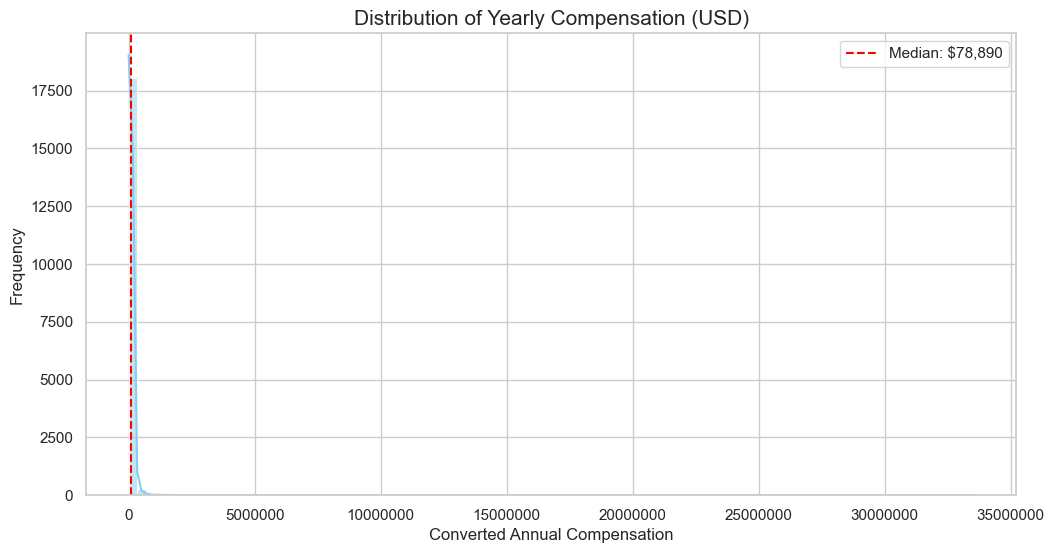

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))

# Plot the histogram of ConvertedCompYearly
sns.histplot(df_expanded['ConvertedCompYearly'], bins=100, kde=True, color='skyblue')

# Add a vertical line for the median salary
median_salary = df_expanded['ConvertedCompYearly'].median()
plt.axvline(median_salary, color='red', linestyle='--', label=f'Median: ${median_salary:,.0f}')

plt.title('Distribution of Yearly Compensation (USD)', fontsize=15)
plt.xlabel('Converted Annual Compensation', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()

# Adjust x-axis to show labels clearly
plt.ticklabel_format(style='plain', axis='x')

plt.show()

### Explore Tools Feature Importance 

In [47]:
import pandas as pd

# 1. Define prefixes and desired column names
multiselect_prefixes = [
    ('LanguageHaveWorkedWith_', 'LanguageHaveWorkedWith'),
    ('DatabaseHaveWorkedWith_', 'DatabaseHaveWorkedWith'),
    ('PlatformHaveWorkedWith_', 'PlatformHaveWorkedWith'),
    ('WebframeHaveWorkedWith_', 'WebframeHaveWorkedWith')
]

desired_column_names = {
    'Tool Name': 'tool',
    'Count': 'user_count',
    'Percentage (%)': 'market_share_%',
    'Median Salary': 'median_salary',
    'Standard Deviation': 'std_dev',
    'Non-User Median Salary': 'non_user_median',
    'AI User Count': 'ai_user_count',
    'Tool AI Adoption (%)': 'tool_ai_adoption_%',
    'Salary Premium': 'salary_premium',
    'Salary Premium (%)': 'salary_premium_%'
}

total_rows = len(df_expanded)

# Function to calculate metrics for a given prefix with a significance threshold
def calculate_metrics(df, prefix, threshold=500):
    summary_data_for_prefix = []
    cols_for_prefix = [col for col in df.columns if col.startswith(prefix)]

    for col in cols_for_prefix:
        tool_name = col.replace(prefix, '')

        # Subset of developers using this specific tool
        subset_users = df[df[col] == 1]
        user_count = len(subset_users)

        # Filter for statistical significance (minimum 500 users)
        if user_count < threshold:
            continue

        non_subset_users = df[df[col] == 0]
        market_share_percentage = (user_count / total_rows) * 100

        # AI Metrics
        ai_users_in_tool = subset_users[subset_users['AISelect'].str.contains('Yes', na=False, case=False)]
        ai_user_count = len(ai_users_in_tool)
        tool_ai_adoption_pct = (ai_user_count / user_count * 100) if user_count > 0 else 0

        # Salary Metrics
        median_salary = subset_users['ConvertedCompYearly'].median()
        std_salary = subset_users['ConvertedCompYearly'].std()
        non_user_median_salary = non_subset_users['ConvertedCompYearly'].median()

        # Premium Metrics
        salary_premium = median_salary - non_user_median_salary
        salary_premium_pct = (salary_premium / non_user_median_salary * 100) if non_user_median_salary > 0 else 0

        summary_data_for_prefix.append({
            'Tool Name': tool_name,
            'Count': user_count,
            'Percentage (%)': market_share_percentage,
            'Median Salary': median_salary,
            'Standard Deviation': std_salary,
            'Non-User Median Salary': non_user_median_salary,
            'AI User Count': ai_user_count,
            'Tool AI Adoption (%)': tool_ai_adoption_pct,
            'Salary Premium': salary_premium,
            'Salary Premium (%)': salary_premium_pct,
            'Category': prefix.replace('_', '')
        })
    return summary_data_for_prefix

# Dynamic sorting function
def display_sorted_table(df_to_sort, title, sort_by_column='median_salary', ascending=False):
    if sort_by_column not in df_to_sort.columns:
        sort_by_column = 'median_salary'

    if pd.api.types.is_numeric_dtype(df_to_sort[sort_by_column]):
        sorted_df = df_to_sort.sort_values(by=sort_by_column, ascending=ascending).reset_index(drop=True)
    else:
        sorted_df = df_to_sort.sort_values(by=sort_by_column, ascending=ascending, key=lambda x: x.str.lower()).reset_index(drop=True)

    print(f"\n{'='*20} {title} {'='*20}")
    print(f"Sorted by '{sort_by_column}', Ascending: {ascending} (Min Users: 400)")
    
    display(sorted_df.round(2))
    return sorted_df

# 2. Iterate over each prefix, create a separate DataFrame, and display it
for prefix_tag, category_name in multiselect_prefixes:
    summary_data = calculate_metrics(df_expanded, prefix_tag)

    current_summary_df = pd.DataFrame(summary_data)
    current_summary_df = current_summary_df.rename(columns=desired_column_names)

    if 'Category' in current_summary_df.columns:
        current_summary_df = current_summary_df.drop(columns=['Category'])

    globals()[f'{category_name.lower()}_summary_df'] = display_sorted_table(
        current_summary_df, 
        title=f"{category_name} Summary",
        sort_by_column='median_salary', 
        ascending=False
    )


==================== LanguageHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby,1257,6.84,105790.0,334121.68,76412.0,1056,84.01,29378.0,38.45
1,Elixir,504,2.74,103634.0,430692.54,78000.0,411,81.55,25634.0,32.86
2,Perl,571,3.11,100000.0,387626.61,77760.0,377,66.02,22240.0,28.60
3,Swift,976,5.31,94685.5,315573.43,77730.0,834,85.45,16955.5,21.81
4,Go,3045,16.57,92812.0,227141.44,75410.0,2590,85.06,17402.0,23.08
5,Groovy,945,5.14,89867.0,245120.35,77993.5,762,80.63,11873.5,15.22
6,Rust,2421,13.17,87951.0,219323.81,76570.0,1893,78.19,11381.0,14.86
7,Bash/Shell (all shells),8593,46.75,87011.0,156033.11,70000.0,6906,80.37,17011.0,24.30
8,PowerShell,4082,22.21,83531.0,159721.28,76340.0,3404,83.39,7191.0,9.42
9,Kotlin,1988,10.82,81685.0,269439.73,78011.0,1705,85.76,3674.0,4.71



==================== DatabaseHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Snowflake,665,3.62,131325.0,410037.05,77000.0,577,86.77,54325.0,70.55
1,Databricks SQL,508,2.76,109299.0,537319.86,77760.0,457,89.96,31539.0,40.56
2,Dynamodb,1717,9.34,103354.0,856338.93,75410.0,1521,88.58,27944.0,37.06
3,Cosmos DB,777,4.23,95000.0,1246539.44,77730.0,679,87.39,17270.0,22.22
4,BigQuery,999,5.43,94000.0,362924.18,77730.0,897,89.79,16270.0,20.93
5,InfluxDB,549,2.99,88492.0,399320.31,78306.0,463,84.34,10186.0,13.01
6,Elasticsearch,2764,15.04,87011.0,300374.00,76570.0,2381,86.14,10441.0,13.64
7,Redis,4766,25.93,83531.0,212431.76,76570.0,4207,88.27,6961.0,9.09
8,PostgreSQL,8854,48.17,80104.5,415863.59,77150.0,7524,84.98,2954.5,3.83
9,Microsoft SQL Server,4756,25.87,80000.0,512432.62,78616.0,3854,81.03,1384.0,1.76



==================== PlatformHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Splunk,676,3.68,120000.0,363786.13,77150.0,580,85.80,42850.0,55.54
1,Datadog,1549,8.43,116015.0,303840.97,75410.0,1344,86.77,40605.0,53.85
2,Terraform,2923,15.90,104413.0,258270.64,73536.0,2498,85.46,30877.0,41.99
3,New Relic,645,3.51,102106.0,370678.17,77730.0,556,86.20,24376.0,31.36
4,Homebrew,4066,22.12,98612.0,214826.63,73089.0,3594,88.39,25523.0,34.92
5,Podman,1572,8.55,94077.0,246639.94,76570.0,1266,80.53,17507.0,22.86
6,Kubernetes,4574,24.88,93972.0,190919.42,73375.0,3882,84.87,20597.0,28.07
7,MSBuild,1793,9.75,93095.0,226378.48,76422.5,1445,80.59,16672.5,21.82
8,Prometheus,1805,9.82,92812.0,279778.71,76570.0,1551,85.93,16242.0,21.21
9,Amazon Web Services (AWS),6842,37.22,92812.0,448785.74,71499.0,5836,85.30,21313.0,29.81



==================== WebframeHaveWorkedWith Summary ====================
Sorted by 'median_salary', Ascending: False (Min Users: 400)


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby on Rails,915,4.98,105966.0,336316.70,76800.0,783,85.57,29166.0,37.98
1,Blazor,1090,5.93,81210.0,219086.29,78633.0,936,85.87,2577.0,3.28
2,Svelte,956,5.20,80277.5,248713.59,78890.0,821,85.88,1387.5,1.76
3,ASP.NET Core,3103,16.88,80254.0,638085.65,78316.0,2595,83.63,1938.0,2.47
4,React,6578,35.79,78778.5,447118.86,78890.0,5753,87.46,-111.5,-0.14
5,Spring Boot,2149,11.69,76097.0,265296.39,78890.0,1852,86.18,-2793.0,-3.54
6,ASP.NET,2116,11.51,75483.0,252852.59,78959.0,1738,82.14,-3476.0,-4.40
7,Node.js,6787,36.92,75472.0,128401.28,80236.5,5839,86.03,-4764.5,-5.94
8,AngularJS,1013,5.51,75410.0,239367.80,78890.0,855,84.40,-3480.0,-4.41
9,Deno,502,2.73,75410.0,335647.51,78890.0,442,88.05,-3480.0,-4.41


### Include only 15%> Salary Premium Columns

In [52]:
%whos

Variable                            Type                   Data/Info
--------------------------------------------------------------------
MultiLabelBinarizer                 type                   <class 'sklearn.preproces<...>bel.MultiLabelBinarizer'>
binarized_data                      ndarray                18381x29: 533049 elems, type `int64`, 4264392 bytes (4.066841125488281 Mb)
binarized_dfs                       dict                   n=4
calculate_metrics                   function               <function calculate_metri<...>cs at 0x000001A6A47C0FE0>
category_name                       str                    WebframeHaveWorkedWith
clean_based_on_id_only              function               <function clean_based_on_<...>ly at 0x000001A6CF7B5D00>
cleaned_unique_count                int                    21527
col                                 str                    WebframeHaveWorkedWith
cols_to_check                       list                   n=3
csv_file_path               

In [60]:
# List of summary tables to analyze
summary_tables = {
    'Languages': 'languagehaveworkedwith_summary_df',
    'Databases': 'databasehaveworkedwith_summary_df',
    'Platforms': 'platformhaveworkedwith_summary_df',
    'Web Frameworks': 'webframehaveworkedwith_summary_df'
}

print("--- Feature Selection Analysis (Absolute Premium > 15%) ---\n")

for label, var_name in summary_tables.items():
    if var_name in globals():
        df_summary = globals()[var_name]
        
        # Filter for absolute premium > 15%
        high_premium_df = df_summary[df_summary['salary_premium_%'].abs() > 15].reset_index(drop=True)
        
        original_count = len(df_summary)
        remaining_count = len(high_premium_df)
        
        print(f"Category: {label}")
        print(f"- Total evaluated (>= 500 users): {original_count}")
        print(f"- Significant features (> 15% premium): {remaining_count}")
        print(f"- Reduction: {original_count - remaining_count} columns dropped")
        
        if not high_premium_df.empty:
            display(high_premium_df.sort_values(by='salary_premium_%', ascending=False))
        else:
            print("  (No tools met the 15% premium threshold)")
        print("-" * 50)
    else:
        print(f"Warning: {var_name} not found in globals. Skipping {label}.")

--- Feature Selection Analysis (Absolute Premium > 15%) ---

Category: Languages
- Total evaluated (>= 500 users): 26
- Significant features (> 15% premium): 9
- Reduction: 17 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby,1257,6.838583,105790.0,334121.680475,76412.0,1056,84.009547,29378.0,38.446841
1,Elixir,504,2.741962,103634.0,430692.541122,78000.0,411,81.547619,25634.0,32.864103
2,Perl,571,3.106469,100000.0,387626.611506,77760.0,377,66.024518,22240.0,28.600823
6,Bash/Shell (all shells),8593,46.749361,87011.0,156033.110695,70000.0,6906,80.367741,17011.0,24.301429
4,Go,3045,16.566019,92812.0,227141.435305,75410.0,2590,85.057471,17402.0,23.076515
3,Swift,976,5.309831,94685.5,315573.425329,77730.0,834,85.450820,16955.5,21.813328
5,Groovy,945,5.141178,89867.0,245120.347718,77993.5,762,80.634921,11873.5,15.223705
7,PHP,3216,17.496328,61264.0,181708.461348,81685.0,2655,82.555970,-20421.0,-24.999694
8,Dart,956,5.201023,55015.5,246223.710304,80000.0,849,88.807531,-24984.5,-31.230625


--------------------------------------------------
Category: Databases
- Total evaluated (>= 500 users): 19
- Significant features (> 15% premium): 11
- Reduction: 8 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Snowflake,665,3.617866,131325.0,4.100370e+05,77000.0,577,86.766917,54325.0,70.551948
1,Databricks SQL,508,2.763723,109299.0,5.373199e+05,77760.0,457,89.960630,31539.0,40.559414
2,Dynamodb,1717,9.341168,103354.0,8.563389e+05,75410.0,1521,88.584741,27944.0,37.056093
3,Cosmos DB,777,4.227191,95000.0,1.246539e+06,77730.0,679,87.387387,17270.0,22.217934
4,BigQuery,999,5.434960,94000.0,3.629242e+05,77730.0,897,89.789790,16270.0,20.931429
6,MariaDB,3127,17.012132,67268.0,1.841793e+05,81210.0,2589,82.795011,-13942.0,-17.167836
5,MySQL,5712,31.075567,68225.0,2.068072e+05,82370.0,4841,84.751401,-14145.0,-17.172514
7,MongoDB,3453,18.785703,66017.0,2.113650e+05,81210.0,3026,87.633942,-15193.0,-18.708287
8,Supabase,866,4.711387,64968.0,4.447329e+05,80000.0,815,94.110855,-15032.0,-18.790000
9,Cloud Firestore,769,4.183668,60000.0,4.827737e+05,80000.0,707,91.937581,-20000.0,-25.000000


--------------------------------------------------
Category: Platforms
- Total evaluated (>= 500 users): 39
- Significant features (> 15% premium): 17
- Reduction: 22 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Splunk,676,3.677711,120000.0,363786.132025,77150.0,580,85.798817,42850.0,55.541154
1,Datadog,1549,8.427180,116015.0,303840.970975,75410.0,1344,86.765655,40605.0,53.845644
2,Terraform,2923,15.902290,104413.0,258270.639957,73536.0,2498,85.460144,30877.0,41.988958
4,Homebrew,4066,22.120668,98612.0,214826.628443,73089.0,3594,88.391540,25523.0,34.920439
3,New Relic,645,3.509058,102106.0,370678.165550,77730.0,556,86.201550,24376.0,31.359835
9,Amazon Web Services (AWS),6842,37.223220,92812.0,448785.737080,71499.0,5836,85.296697,21313.0,29.808809
6,Kubernetes,4574,24.884391,93972.0,190919.418458,73375.0,3882,84.871010,20597.0,28.070869
5,Podman,1572,8.552309,94077.0,246639.935856,76570.0,1266,80.534351,17507.0,22.864046
11,Make,3222,17.528970,92497.0,215081.231481,75410.0,2574,79.888268,17087.0,22.658799
7,MSBuild,1793,9.754638,93095.0,226378.477200,76422.5,1445,80.591188,16672.5,21.816219


--------------------------------------------------
Category: Web Frameworks
- Total evaluated (>= 500 users): 24
- Significant features (> 15% premium): 8
- Reduction: 16 columns dropped


,tool,user_count,market_share_%,median_salary,std_dev,non_user_median,ai_user_count,tool_ai_adoption_%,salary_premium,salary_premium_%
0,Ruby on Rails,915,4.977966,105966.0,336316.702332,76800.0,783,85.573770,29166.0,37.976562
1,Express,2709,14.738045,67779.0,162325.836773,81038.0,2424,89.479513,-13259.0,-16.361460
2,WordPress,1669,9.080028,66156.0,842394.660241,80000.0,1442,86.399041,-13844.0,-17.305000
3,Nuxt.js,557,3.030303,64968.0,320508.927576,79062.0,496,89.048474,-14094.0,-17.826516
4,Django,1571,8.546869,63808.0,345998.808500,80000.0,1380,87.842139,-16192.0,-20.240000
5,NestJS,1017,5.532887,63808.0,228061.567785,80000.0,940,92.428712,-16192.0,-20.240000
6,Symfony,619,3.367608,63808.0,283320.922859,80000.0,530,85.621971,-16192.0,-20.240000
7,Laravel,1241,6.751537,52207.0,205810.265969,81210.0,1097,88.396454,-29003.0,-35.713582


--------------------------------------------------


## EDA Summary & Modelling Rationale

Feature selection basis: salary premium threshold of ±15% applied to scouting 
tables across Languages, Databases, Platforms, and Webframes. Minimum user count 
of 500 applied for median reliability.

Target variable: ConvertedCompYearly (USD). Distribution check required before 
modelling — log transformation to be applied if right-skewed.

Confounding variable identified: WorkExp (experience). Included as primary feature in all models so that AI usage coefficient/SHAP value represents marginal contribution above experience. This is the control mechanism for the research question.

Secondary confounders: Country (structural salary distortion), DevType (seniority proxy), Industry (compensation culture variation). All included as model features.

Class balance: [fill in after checking] % of dataset uses AI tools.